In [3]:
# Core
import pandas as pd
import numpy as np

# Model loading
import joblib

# (Optional) Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import joblib

model = joblib.load('../models/churn_model.pkl')

In [12]:

df_full = pd.read_csv('../data/processed_data.csv')

# same preprocessing fix if needed
for col in df_full.columns:
    if str(df_full[col].dtype) == 'string':
        df_full[col] = df_full[col].astype('object')

X_full = df_full.drop('Churn', axis=1)

df_full['churn_probability'] = model.predict_proba(X_full)[:, 1]

In [14]:
df_full['business_score'] = df_full['churn_probability'] * df_full['CLV']

df_full = df_full.sort_values(by='business_score', ascending=False)

top_customers = df_full.head(50)
top_customers

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,charge_per_tenure,avg_charge_diff,num_services,high_risk,contract_type_encoded,tenure_group,CLV,churn_probability,business_score
2874,4550-VBOFE,Male,1,Yes,No,70,Yes,Yes,Fiber optic,No,...,1,100.021127,2.928873,5,0,0,4-6yr,7206.50,0.596046,4295.406722
6023,9090-SGQXL,Male,1,Yes,No,68,Yes,Yes,Fiber optic,No,...,1,105.792029,-0.492029,5,0,0,4-6yr,7160.40,0.592027,4239.153064
2604,4446-BZKHU,Male,0,Yes,No,61,Yes,Yes,Fiber optic,No,...,1,101.313710,4.236290,5,0,0,4-6yr,6438.55,0.614296,3955.178533
4076,0324-BRPCJ,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,...,1,99.299275,0.900725,4,0,0,4-6yr,6813.60,0.579377,3947.640931
339,1343-EHPYB,Male,0,Yes,No,63,Yes,Yes,Fiber optic,No,...,1,103.171875,0.228125,5,0,0,4-6yr,6514.20,0.598630,3899.593622
2272,3571-RFHAR,Male,0,No,No,65,Yes,Yes,Fiber optic,No,...,1,105.169697,3.980303,6,0,0,4-6yr,7094.75,0.534099,3789.299111
4387,5502-RLUYV,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,...,1,106.384286,-2.434286,5,0,0,4-6yr,7172.55,0.527655,3784.632362
4067,0946-CLJTI,Male,1,Yes,No,58,Yes,Yes,Fiber optic,No,...,1,98.518644,0.181356,4,0,0,4-6yr,5724.60,0.656795,3759.886821
634,7207-RMRDB,Female,0,Yes,Yes,65,Yes,Yes,Fiber optic,No,...,1,105.843182,-0.343182,5,0,0,4-6yr,6857.50,0.545091,3737.959726
3195,0895-DQHEW,Male,0,Yes,No,54,Yes,Yes,Fiber optic,No,...,1,95.966364,8.333636,5,0,0,4-6yr,5632.20,0.654848,3688.232636


In [15]:
final_cols = [
    'customerID',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CLV',
    'churn_probability',
    'business_score',
    'Contract',
    'InternetService',
    'num_services'
]

top_customers_final = top_customers[final_cols]
top_customers_final.head(10)

,customerID,tenure,MonthlyCharges,TotalCharges,CLV,churn_probability,business_score,Contract,InternetService,num_services
2874,4550-VBOFE,70,102.95,7101.50,7206.50,0.596046,4295.406722,Month-to-month,Fiber optic,5
6023,9090-SGQXL,68,105.30,7299.65,7160.40,0.592027,4239.153064,Month-to-month,Fiber optic,5
2604,4446-BZKHU,61,105.55,6281.45,6438.55,0.614296,3955.178533,Month-to-month,Fiber optic,5
4076,0324-BRPCJ,68,100.20,6851.65,6813.60,0.579377,3947.640931,Month-to-month,Fiber optic,4
339,1343-EHPYB,63,103.40,6603.00,6514.20,0.598630,3899.593622,Month-to-month,Fiber optic,5
2272,3571-RFHAR,65,109.15,6941.20,7094.75,0.534099,3789.299111,Month-to-month,Fiber optic,6
4387,5502-RLUYV,69,103.95,7446.90,7172.55,0.527655,3784.632362,Month-to-month,Fiber optic,5
4067,0946-CLJTI,58,98.70,5812.60,5724.60,0.656795,3759.886821,Month-to-month,Fiber optic,4
634,7207-RMRDB,65,105.50,6985.65,6857.50,0.545091,3737.959726,Month-to-month,Fiber optic,5
3195,0895-DQHEW,54,104.30,5278.15,5632.20,0.654848,3688.232636,Month-to-month,Fiber optic,5


In [16]:
def recommend_action(row):
    if row['Contract'] == 'Month-to-month':
        return 'Offer long-term contract discount'
    elif row['MonthlyCharges'] > 80:
        return 'Give pricing retention offer'
    elif row['num_services'] <= 2:
        return 'Offer bundle upgrade'
    else:
        return 'Retention call by support team'

df_full['recommended_action'] = df_full.apply(recommend_action, axis=1)

top_customers = df_full.sort_values(by='business_score', ascending=False).head(50)

final_cols = [
    'customerID',
    'tenure',
    'MonthlyCharges',
    'CLV',
    'churn_probability',
    'business_score',
    'Contract',
    'num_services',
    'recommended_action'
]

top_customers_final = top_customers[final_cols]
top_customers_final.head(10)

,customerID,tenure,MonthlyCharges,CLV,churn_probability,business_score,Contract,num_services,recommended_action
2874,4550-VBOFE,70,102.95,7206.50,0.596046,4295.406722,Month-to-month,5,Offer long-term contract discount
6023,9090-SGQXL,68,105.30,7160.40,0.592027,4239.153064,Month-to-month,5,Offer long-term contract discount
2604,4446-BZKHU,61,105.55,6438.55,0.614296,3955.178533,Month-to-month,5,Offer long-term contract discount
4076,0324-BRPCJ,68,100.20,6813.60,0.579377,3947.640931,Month-to-month,4,Offer long-term contract discount
339,1343-EHPYB,63,103.40,6514.20,0.598630,3899.593622,Month-to-month,5,Offer long-term contract discount
2272,3571-RFHAR,65,109.15,7094.75,0.534099,3789.299111,Month-to-month,6,Offer long-term contract discount
4387,5502-RLUYV,69,103.95,7172.55,0.527655,3784.632362,Month-to-month,5,Offer long-term contract discount
4067,0946-CLJTI,58,98.70,5724.60,0.656795,3759.886821,Month-to-month,4,Offer long-term contract discount
634,7207-RMRDB,65,105.50,6857.50,0.545091,3737.959726,Month-to-month,5,Offer long-term contract discount
3195,0895-DQHEW,54,104.30,5632.20,0.654848,3688.232636,Month-to-month,5,Offer long-term contract discount


In [17]:
top_customers_final.to_csv('../data/top_50_customers_to_target.csv', index=False)

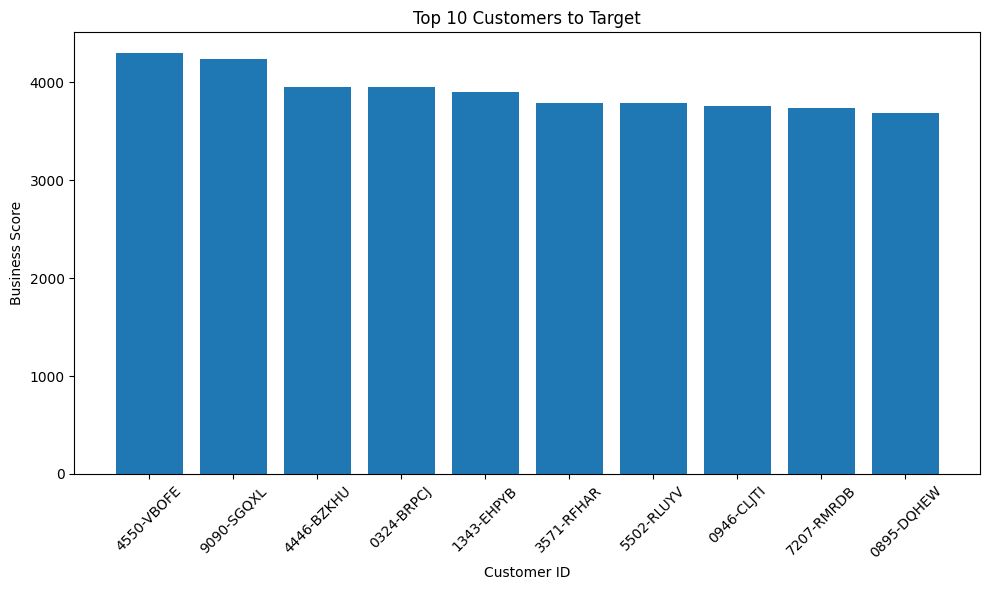

In [18]:
import matplotlib.pyplot as plt

top10 = top_customers_final.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['customerID'], top10['business_score'])
plt.xticks(rotation=45)
plt.ylabel('Business Score')
plt.xlabel('Customer ID')
plt.title('Top 10 Customers to Target')
plt.tight_layout()
plt.show()

* “After predicting churn probability, we added a business prioritization layer by combining churn risk with estimated customer lifetime value. This allowed us to rank customers by potential revenue impact and recommend retention actions for the top-risk, high-value customers.”

And for why this matters:

“A company usually cannot target everyone, so this layer helps allocate retention budget efficiently.”